In [1]:
import pandas as pd

file_path = "I:\Projects\iocl\data\dataset.xlsx"

# Load all sheets at once
sheets = pd.read_excel(file_path, sheet_name=None, parse_dates=True)

# Assign each sheet to its own DataFrame
# Replace sheet names below with the actual names from your workbook
df_process = sheets["Sheet1"]       # Sheet 1: process variables with dates
df_weather = sheets["LPG weathering data"]  # Sheet 2: weathering temperature with dates

print(df_process.head())
print(df_weather.head())
print(df_weather.columns.tolist())

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Vansh Pandey\AppData\Local\Temp\ipykernel_3276\537447304.py:3: SyntaxWarning: invalid escape sequence '\P'
  file_path = "I:\Projects\iocl\data\dataset.xlsx"


        DATE Stabilizer Feed T Stabilizer Feed Flow  Stabilizer Top P  \
0        NaT   PNA.03TI1902.PV      pna.03fc1901.pv  PNA.03PC1901B.PV   
1        NaT              DEGC                M3/HR            KG/CM2   
2 2024-06-13            132.41               195.67               9.8   
3 2024-06-14            133.49               182.73               9.8   
4 2024-06-15            133.48               225.02               9.8   

  Stabilizer Reflux Drum T Stabilized Naphtha Flow Stabilizer Reflux Flow  \
0          PNA.03TI1916.PV         PNA.03FC2001.PV        pna.03fc1902.pv   
1                     DEGC                   M3/HR                  M3/HR   
2                    28.19                  165.97                  82.02   
3                    30.17                  152.45                  87.86   
4                    30.17                  190.58                  83.24   

       HGO CR Flow HGO CR to reboiler Flow         LPG Flow  ...  \
0  pna.03fi1604.pv         pna

In [2]:
import pandas as pd

# Convert Date columns to datetime (dayfirst=True handles DD.MM.YYYY format)
df_process["DATE"] = pd.to_datetime(df_process["DATE"], format="%d.%m.%Y")
df_weather["DATE"] = pd.to_datetime(df_weather["DATE"], format="%d.%m.%Y")

# Left join on DATE
df_merged = pd.merge(df_process, df_weather, on="DATE", how="left")

# Report matched vs unmatched rows
matched   = df_merged["Wthr"].notna().sum()
unmatched = df_merged["Wthr"].isna().sum()

print(f"Total rows in df_process : {len(df_process)}")
print(f"Matched rows             : {matched}")
print(f"Unmatched rows           : {unmatched}")

# Keep only rows where 'Wthr' is present
df_clean = df_merged[df_merged["Wthr"].notna()].copy()

# Verify no missing target values
assert df_clean["Wthr"].isna().sum() == 0, "Still has missing Wthr values!"

# Print final shape
print(f"Original shape : {df_merged.shape}")
print(f"Clean shape    : {df_clean.shape}")
print(f"Rows dropped   : {len(df_merged) - len(df_clean)}")

Total rows in df_process : 733
Matched rows             : 472
Unmatched rows           : 273
Original shape : (745, 25)
Clean shape    : (472, 25)
Rows dropped   : 273


In [3]:
print(f"Shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns\n")
print("Data Types:")
print(df_clean.dtypes)

Shape: 472 rows × 25 columns

Data Types:
DATE                                                      datetime64[ns]
Stabilizer Feed T                                                 object
Stabilizer Feed Flow                                              object
Stabilizer Top P                                                  object
Stabilizer Reflux Drum T                                          object
Stabilized Naphtha Flow                                           object
Stabilizer Reflux Flow                                            object
HGO CR Flow                                                       object
HGO CR to reboiler Flow                                           object
LPG Flow                                                          object
Stabilizer Top T                                                  object
Stabilizer Top T.1                                                object
Stabilizer Bottom T                                               object
Stabilise

In [4]:
missing = df_clean.isnull().sum()

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df_clean) * 100).round(2)
})

missing_report[missing_report["Missing Count"] > 0]

,Missing Count,Missing %
DATE,14,2.97
Stab. 32 Tray,458,97.03


In [5]:
df_clean.duplicated().sum()

np.int64(2)

In [6]:
df_clean["Wthr"].value_counts().sort_index()

Wthr
-4.0      1
-3.4      2
-3.2      2
-3.0     19
-2.6      3
-2.2      2
-2.0    113
-1.6      2
-1.4      1
-1.0    170
-0.8      5
-0.6      3
-0.5      1
-0.4      2
-0.2      2
 0.0     71
 0.2      2
 0.4      2
 0.6      3
 0.8      4
 1.0     43
 1.1      1
 1.2      2
 1.4      1
 1.8      1
 2.0      7
 2.4      2
 2.8      1
 3.0      3
 5.0      1
Name: count, dtype: int64

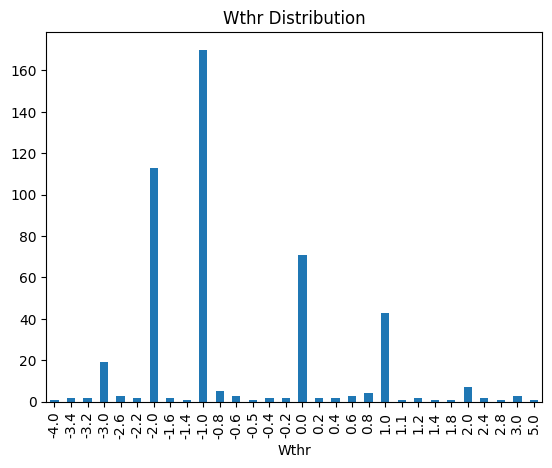

In [7]:
import matplotlib.pyplot as plt

df_clean["Wthr"].value_counts().sort_index().plot(kind="bar")
plt.title("Wthr Distribution")
plt.show()

In [8]:
df_clean[df_clean["DATE"].isnull()]

,DATE,Stabilizer Feed T,Stabilizer Feed Flow,Stabilizer Top P,Stabilizer Reflux Drum T,Stabilized Naphtha Flow,Stabilizer Reflux Flow,HGO CR Flow,HGO CR to reboiler Flow,LPG Flow,...,Stab. 3rd Tray,Stab. 3rd Tray.1,Stab. 32 Tray,HGO CR Reboiler Inlet Temp( TI-1914),Bottom Reboiler Naphtha Inlet Temp( TI-1907),Bot. Naphtha Reboiler Outlet Temp(TI-1908 & TI-1909),Bot. Naphtha Reboiler Outlet Temp(TI-1908 & TI-1909).1,Off Spec LPG flow (tag Faulty),Off Spec LPG from CRU inlet pressure,Wthr
0,NaT,PNA.03TI1902.PV,pna.03fc1901.pv,PNA.03PC1901B.PV,PNA.03TI1916.PV,PNA.03FC2001.PV,pna.03fc1902.pv,pna.03fi1604.pv,pna.03FC1904.pv,PNA.03FC2701.PV,...,PNA.03TI1906.PV,PNA.03TI1905.PV,PNA.03TC1904.PV,PNA.03TI1914.PV,PNA.03TI1907.PV,PNA.03TI1908.PV,PNA.03TI1909.PV,PNA.08FI2703a.PV,pna.03PC1903.PV,-2.0
1,NaT,PNA.03TI1902.PV,pna.03fc1901.pv,PNA.03PC1901B.PV,PNA.03TI1916.PV,PNA.03FC2001.PV,pna.03fc1902.pv,pna.03fi1604.pv,pna.03FC1904.pv,PNA.03FC2701.PV,...,PNA.03TI1906.PV,PNA.03TI1905.PV,PNA.03TC1904.PV,PNA.03TI1914.PV,PNA.03TI1907.PV,PNA.03TI1908.PV,PNA.03TI1909.PV,PNA.08FI2703a.PV,pna.03PC1903.PV,0.0
2,NaT,PNA.03TI1902.PV,pna.03fc1901.pv,PNA.03PC1901B.PV,PNA.03TI1916.PV,PNA.03FC2001.PV,pna.03fc1902.pv,pna.03fi1604.pv,pna.03FC1904.pv,PNA.03FC2701.PV,...,PNA.03TI1906.PV,PNA.03TI1905.PV,PNA.03TC1904.PV,PNA.03TI1914.PV,PNA.03TI1907.PV,PNA.03TI1908.PV,PNA.03TI1909.PV,PNA.08FI2703a.PV,pna.03PC1903.PV,-2.0
3,NaT,PNA.03TI1902.PV,pna.03fc1901.pv,PNA.03PC1901B.PV,PNA.03TI1916.PV,PNA.03FC2001.PV,pna.03fc1902.pv,pna.03fi1604.pv,pna.03FC1904.pv,PNA.03FC2701.PV,...,PNA.03TI1906.PV,PNA.03TI1905.PV,PNA.03TC1904.PV,PNA.03TI1914.PV,PNA.03TI1907.PV,PNA.03TI1908.PV,PNA.03TI1909.PV,PNA.08FI2703a.PV,pna.03PC1903.PV,1.0
4,NaT,PNA.03TI1902.PV,pna.03fc1901.pv,PNA.03PC1901B.PV,PNA.03TI1916.PV,PNA.03FC2001.PV,pna.03fc1902.pv,pna.03fi1604.pv,pna.03FC1904.pv,PNA.03FC2701.PV,...,PNA.03TI1906.PV,PNA.03TI1905.PV,PNA.03TC1904.PV,PNA.03TI1914.PV,PNA.03TI1907.PV,PNA.03TI1908.PV,PNA.03TI1909.PV,PNA.08FI2703a.PV,pna.03PC1903.PV,-1.0
5,NaT,PNA.03TI1902.PV,pna.03fc1901.pv,PNA.03PC1901B.PV,PNA.03TI1916.PV,PNA.03FC2001.PV,pna.03fc1902.pv,pna.03fi1604.pv,pna.03FC1904.pv,PNA.03FC2701.PV,...,PNA.03TI1906.PV,PNA.03TI1905.PV,PNA.03TC1904.PV,PNA.03TI1914.PV,PNA.03TI1907.PV,PNA.03TI1908.PV,PNA.03TI1909.PV,PNA.08FI2703a.PV,pna.03PC1903.PV,-0.8
6,NaT,PNA.03TI1902.PV,pna.03fc1901.pv,PNA.03PC1901B.PV,PNA.03TI1916.PV,PNA.03FC2001.PV,pna.03fc1902.pv,pna.03fi1604.pv,pna.03FC1904.pv,PNA.03FC2701.PV,...,PNA.03TI1906.PV,PNA.03TI1905.PV,PNA.03TC1904.PV,PNA.03TI1914.PV,PNA.03TI1907.PV,PNA.03TI1908.PV,PNA.03TI1909.PV,PNA.08FI2703a.PV,pna.03PC1903.PV,-2.6
7,NaT,DEGC,M3/HR,KG/CM2,DEGC,M3/HR,M3/HR,M3/HR,M3/HR,M3/HR,...,DEGC,DEGC,#ERROR# - At least one Valid Tag Name is required,DEGC,DEGC,DEGC,DEGC,M3/HR,KG/CM2,-2.0
8,NaT,DEGC,M3/HR,KG/CM2,DEGC,M3/HR,M3/HR,M3/HR,M3/HR,M3/HR,...,DEGC,DEGC,#ERROR# - At least one Valid Tag Name is required,DEGC,DEGC,DEGC,DEGC,M3/HR,KG/CM2,0.0
9,NaT,DEGC,M3/HR,KG/CM2,DEGC,M3/HR,M3/HR,M3/HR,M3/HR,M3/HR,...,DEGC,DEGC,#ERROR# - At least one Valid Tag Name is required,DEGC,DEGC,DEGC,DEGC,M3/HR,KG/CM2,-2.0


In [9]:
print(df_clean.shape)

print(df_clean.isnull().sum().sum())


(472, 25)
472


In [10]:
# Remove the 'Stab. 32 Tray' column
df_clean = df_clean.drop(columns=["Stab. 32 Tray"])

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Reset index
df_clean = df_clean.reset_index(drop=True)

In [11]:
print(df_clean.isnull().sum().sum())

12


In [12]:
df_clean = df_clean.dropna().reset_index(drop=True)

In [13]:
print(df_clean.shape)
print(df_clean.isnull().sum().sum())
print(df_clean.duplicated().sum())

(458, 24)
0
0


In [14]:
print(df_clean["Wthr"].describe())

print("\nMedian:", df_clean["Wthr"].median())
print("Variance:", df_clean["Wthr"].var())
print("Unique values:", df_clean["Wthr"].nunique())

count    458.000000
mean      -0.847598
std        1.225569
min       -4.000000
25%       -2.000000
50%       -1.000000
75%        0.000000
max        5.000000
Name: Wthr, dtype: float64

Median: -1.0
Variance: 1.5020182890122593
Unique values: 30


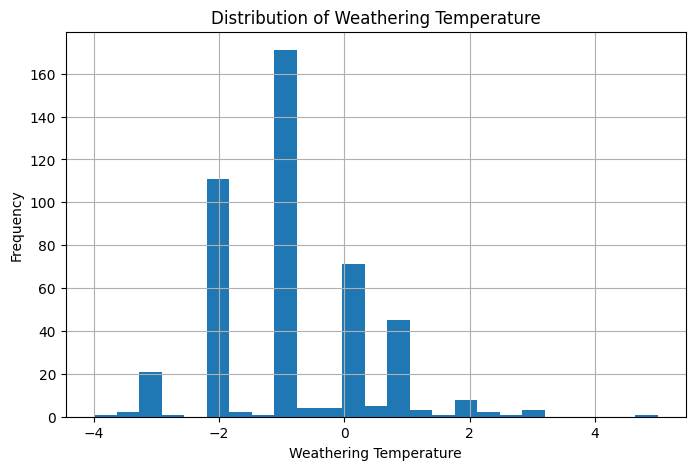

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["Wthr"], bins=25)
plt.title("Distribution of Weathering Temperature")
plt.xlabel("Weathering Temperature")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [16]:
# Convert all columns except DATE to numeric
feature_cols = df_clean.columns.drop("DATE")

df_clean[feature_cols] = df_clean[feature_cols].apply(pd.to_numeric)

print(df_clean.dtypes)

DATE                                                      datetime64[ns]
Stabilizer Feed T                                                float64
Stabilizer Feed Flow                                             float64
Stabilizer Top P                                                 float64
Stabilizer Reflux Drum T                                         float64
Stabilized Naphtha Flow                                          float64
Stabilizer Reflux Flow                                           float64
HGO CR Flow                                                      float64
HGO CR to reboiler Flow                                          float64
LPG Flow                                                         float64
Stabilizer Top T                                                 float64
Stabilizer Top T.1                                               float64
Stabilizer Bottom T                                              float64
Stabiliser bottom level                            

In [17]:
X = df_clean.drop(columns=["DATE", "Wthr"])
y = df_clean["Wthr"]

In [18]:
df_clean.to_csv(
    r"I:\Projects\iocl\data\df_clean.csv",
    index=False
)